
A_17-09-26
Peak detection group: high_prominence
window = 11, polyorder = 2, prominence = 20, distance = 20

Candidate peaks:
2theta (deg)    prominence
    41.700        614.79
    48.550        315.65
    71.050        175.24
    85.850        204.21
    90.650         63.11

Fitted peaks:
Peak    2theta (deg)    uncertainty    intensity          d (A)       d uncertainty
   1       41.7138        0.0018          739.21       2.16355       0.00009
   2       48.5482        0.0027          365.02       1.87374       0.00010
   3       71.0812        0.0048          176.28       1.32518       0.00008
   4       85.9070        0.0051          183.84       1.13046       0.00005
   5       90.7545        0.0140           45.93       1.08227       0.00013

chi² = 3979.06
dof = 1984
reduced χ² = 2.006

A_17-09-26_2
Peak detection group: high_prominence
window = 11, polyorder = 2, prominence = 20, distance = 20

Candidate peaks:
2theta (deg)    prominence
    41.700        627.51
    48.550

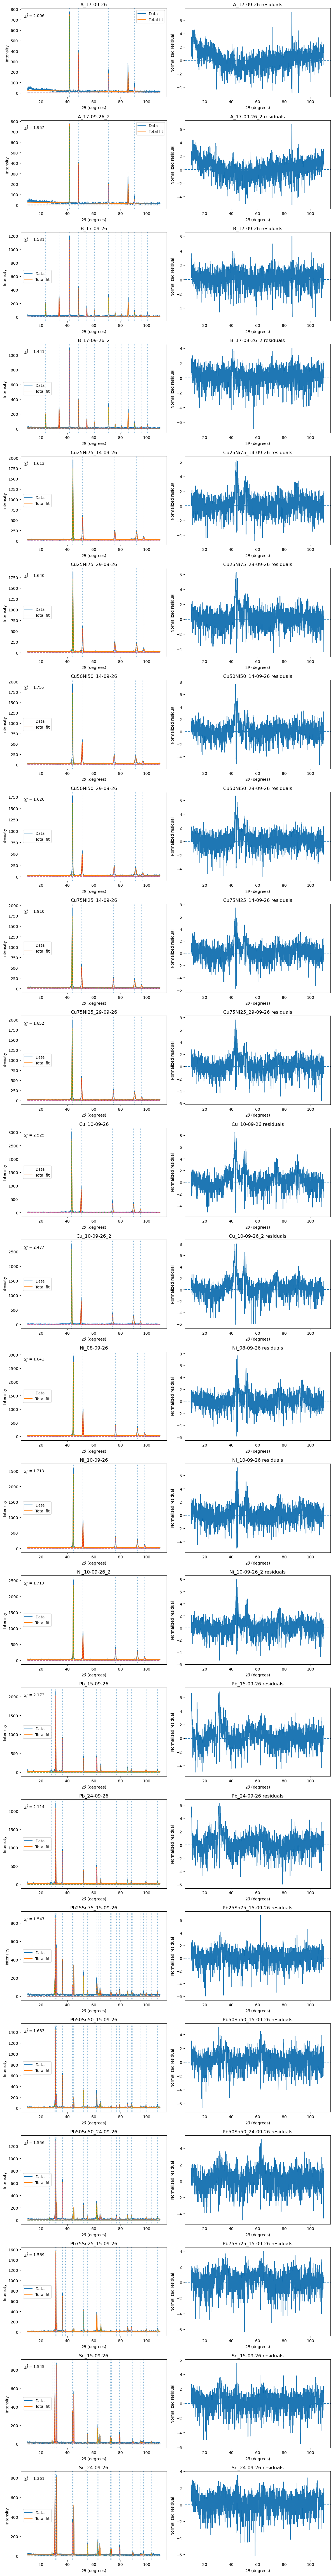

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit
from glob import glob
import os

# ============================================================
# FILES
# ============================================================

high_files = sorted(glob("XRD_data/high_prominence/*.UXD"))
low_files = sorted(glob("XRD_data/low_prominence/*.UXD"))

files = high_files + low_files

# ============================================================
# PEAK-DETECTION SETTINGS
# Adjust these independently for the two groups
# ============================================================

high_settings = {
    "window_length": 11,
    "polyorder": 2,
    "prominence": 20,
    "distance": 20
}

low_settings = {
    "window_length": 11,
    "polyorder": 2,
    "prominence": 12,
    "distance": 12
}

# ============================================================
# PLOT SETUP
# ============================================================

fig, axes = plt.subplots(
    len(files), 2,
    figsize=(12, 4 * len(files))
)

if len(files) == 1:
    axes = np.array([axes])

data_axes = axes[:, 0]
residual_axes = axes[:, 1]

# ============================================================
# OUTPUT DICTIONARIES
# KEEP THESE NAMES UNCHANGED
# ============================================================

peak_angles = {}
peak_intensities = {}
peak_d = {}
peak_angle_errors = {}
peak_d_errors = {}

# ============================================================
# FUNCTIONS
# ============================================================

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def gaussian_sum(x, *params):
    m = params[0]
    b = params[1]

    y = m * x + b

    for i in range(2, len(params), 3):
        A = params[i]
        mu = params[i + 1]
        sigma = params[i + 2]

        y += gaussian(x, A, mu, sigma)

    return y


wavelength = 1.5406
n = 1

# ============================================================
# MAIN LOOP
# ============================================================

for i, file in enumerate(files):

    data = np.loadtxt(file)

    twotheta = data[:, 0]
    intensity = data[:, 1]

    # Poisson uncertainty
    intensity_error = np.sqrt(
        np.maximum(intensity, 1)
    )

    # --------------------------------------------------------
    # SELECT SETTINGS BASED ON SUBFOLDER
    # --------------------------------------------------------

    if "high_prominence" in file:
        settings = high_settings
        group = "high_prominence"

    elif "low_prominence" in file:
        settings = low_settings
        group = "low_prominence"

    else:
        raise ValueError(
            f"File is not inside high_prominence or "
            f"low_prominence: {file}"
        )

    # --------------------------------------------------------
    # PEAK DETECTION
    # Smooth only for finding candidate peaks.
    # Original raw data is still used for the actual fit.
    # --------------------------------------------------------

    smoothed_intensity = savgol_filter(
        intensity,
        window_length=settings["window_length"],
        polyorder=settings["polyorder"]
    )

    peaks, properties = find_peaks(
        smoothed_intensity,
        prominence=settings["prominence"],
        distance=settings["distance"]
    )

    # Only allow peaks at 2theta >= 20 degrees
    valid = twotheta[peaks] >= 20

    peaks = peaks[valid]
    prominences = properties["prominences"][valid]

    rough_positions = twotheta[peaks]
    rough_heights = intensity[peaks]

    # --------------------------------------------------------
    # PRINT CANDIDATE PEAKS
    # --------------------------------------------------------

    name = os.path.basename(file).replace(
        ".UXD", ""
    )

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(f"Peak detection group: {group}")

    print(
        f"window = {settings['window_length']}, "
        f"polyorder = {settings['polyorder']}, "
        f"prominence = {settings['prominence']}, "
        f"distance = {settings['distance']}"
    )

    print("\nCandidate peaks:")
    print("2theta (deg)    prominence")

    for position, prominence in zip(
        rough_positions,
        prominences
    ):
        print(
            f"{position:10.3f}    "
            f"{prominence:10.2f}"
        )

    # --------------------------------------------------------
    # INITIAL GUESS FOR GAUSSIAN FIT
    # --------------------------------------------------------

    initial_guess = [
        0,
        np.min(intensity)
    ]

    for position, height in zip(
        rough_positions,
        rough_heights
    ):

        initial_guess.extend([
            height,
            position,
            0.15
        ])

    # --------------------------------------------------------
    # BOUNDS
    # --------------------------------------------------------

    lower_bounds = [
        -np.inf,
        0
    ]

    upper_bounds = [
        np.inf,
        np.inf
    ]

    for position in rough_positions:

        lower_bounds.extend([
            0,
            position - 1.0,
            0.01
        ])

        upper_bounds.extend([
            np.inf,
            position + 1.0,
            1.0
        ])

    # --------------------------------------------------------
    # GAUSSIAN FIT
    # --------------------------------------------------------

    try:

        popt, pcov = curve_fit(
            gaussian_sum,
            twotheta,
            intensity,
            p0=initial_guess,
            sigma=intensity_error,
            absolute_sigma=True,
            bounds=(
                lower_bounds,
                upper_bounds
            ),
            maxfev=50000
        )

        perr = np.sqrt(
            np.diag(pcov)
        )

        fit_success = True

    except (RuntimeError, ValueError):

        print(
            "Fit failed for:",
            file
        )

        fit_success = False

    # --------------------------------------------------------
    # PROCESS FIT
    # --------------------------------------------------------

    if fit_success:

        fitted_angles = []
        fitted_intensities = []
        fitted_d = []
        fitted_angle_errors = []
        fitted_d_errors = []

        fit = gaussian_sum(
            twotheta,
            *popt
        )

        residuals = (
            intensity - fit
        )

        normalized_residuals = (
            residuals / intensity_error
        )

        chi_squared = np.sum(
            (residuals / intensity_error)**2
        )

        N = len(intensity)

        n_parameters = len(popt)

        degrees_of_freedom = (
            N - n_parameters
        )

        reduced_chi_squared = (
            chi_squared /
            degrees_of_freedom
        )

        # ----------------------------------------------------
        # EXTRACT INDIVIDUAL PEAKS
        # ----------------------------------------------------

        for j in range(
            len(rough_positions)
        ):

            A = popt[2 + 3*j]

            mu = popt[
                2 + 3*j + 1
            ]

            sigma = popt[
                2 + 3*j + 2
            ]

            mu_error = perr[
                2 + 3*j + 1
            ]

            # Bragg angle
            theta = np.radians(
                mu / 2
            )

            # d-spacing
            d = wavelength / (
                2 * np.sin(theta)
            )

            # Propagate uncertainty
            d_error = (
                wavelength
                / (2 * np.sin(theta)**2)
                * np.cos(theta)
                * (np.radians(mu_error) / 2)
            )

            fitted_angles.append(mu)
            fitted_intensities.append(A)
            fitted_d.append(d)
            fitted_angle_errors.append(
                mu_error
            )
            fitted_d_errors.append(
                d_error
            )

        # ----------------------------------------------------
        # SAVE RESULTS
        # ----------------------------------------------------

        peak_angles[name] = np.array(
            fitted_angles
        )

        peak_intensities[name] = np.array(
            fitted_intensities
        )

        peak_d[name] = np.array(
            fitted_d
        )

        peak_angle_errors[name] = np.array(
            fitted_angle_errors
        )

        peak_d_errors[name] = np.array(
            fitted_d_errors
        )

        # ----------------------------------------------------
        # PRINT FITTED RESULTS
        # ----------------------------------------------------

        print("\nFitted peaks:")

        print(
            "Peak    2theta (deg)    uncertainty    "
            "intensity          d (A)       d uncertainty"
        )

        for j in range(
            len(fitted_angles)
        ):

            print(
                f"{j+1:4d}    "
                f"{fitted_angles[j]:10.4f}    "
                f"{fitted_angle_errors[j]:10.4f}    "
                f"{fitted_intensities[j]:12.2f}    "
                f"{fitted_d[j]:10.5f}    "
                f"{fitted_d_errors[j]:10.5f}"
            )

        print(
            f"\nchi² = {chi_squared:.2f}"
        )

        print(
            f"dof = {degrees_of_freedom}"
        )

        print(
            f"reduced χ² = "
            f"{reduced_chi_squared:.3f}"
        )

        # ----------------------------------------------------
        # PLOT DATA + FIT
        # ----------------------------------------------------

        ax = data_axes[i]

        ax.plot(
            twotheta,
            intensity,
            label="Data"
        )

        ax.plot(
            twotheta,
            fit,
            label="Total fit"
        )

        # Plot individual Gaussian peaks
        for j in range(
            len(rough_positions)
        ):

            A = popt[2 + 3*j]

            mu = popt[
                2 + 3*j + 1
            ]

            sigma = popt[
                2 + 3*j + 2
            ]

            individual_peak = gaussian(
                twotheta,
                A,
                mu,
                sigma
            )

            ax.plot(
                twotheta,
                individual_peak,
                "--",
                alpha=0.7
            )

            ax.axvline(
                mu,
                linestyle=":",
                alpha=0.5
            )

        ax.set_title(name)

        ax.set_xlabel(
            r"$2\theta$ (degrees)"
        )

        ax.set_ylabel("Intensity")

        ax.legend()

        ax.text(
            0.02,
            0.95,
            rf"$\chi^2_r = "
            rf"{reduced_chi_squared:.3f}$",
            transform=ax.transAxes,
            verticalalignment="top"
        )

        # ----------------------------------------------------
        # RESIDUALS
        # ----------------------------------------------------

        ax_res = residual_axes[i]

        ax_res.axhline(
            0,
            linestyle="--"
        )

        ax_res.plot(
            twotheta,
            normalized_residuals
        )

        ax_res.set_title(
            f"{name} residuals"
        )

        ax_res.set_xlabel(
            r"$2\theta$ (degrees)"
        )

        ax_res.set_ylabel(
            r"Normalized residual"
        )

    else:

        # If fit fails, still show raw data
        ax = data_axes[i]

        ax.plot(
            twotheta,
            intensity,
            label="Data"
        )

        ax.set_title(
            name + " (fit failed)"
        )

        ax.set_xlabel(
            r"$2\theta$ (degrees)"
        )

        ax.set_ylabel("Intensity")

        ax.legend()


plt.tight_layout()
plt.show()

In [20]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

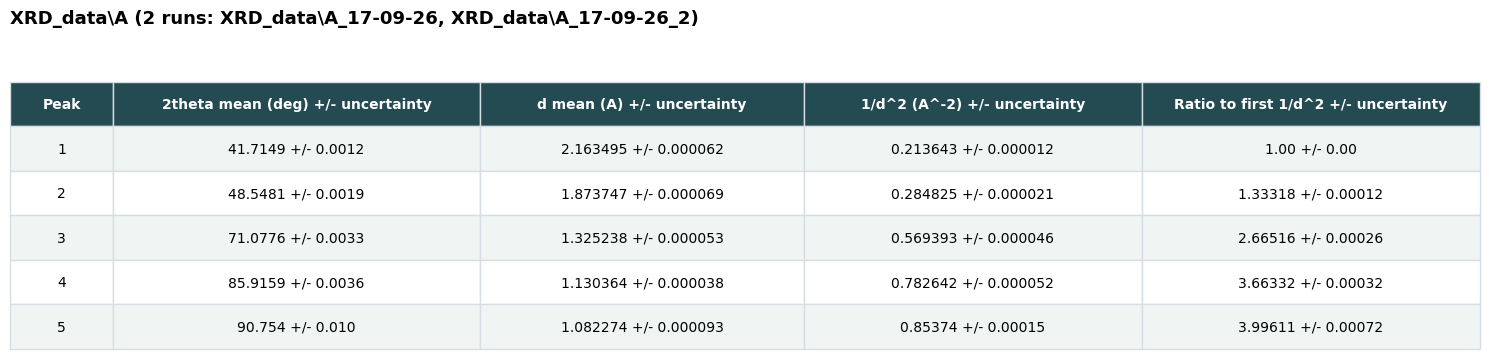

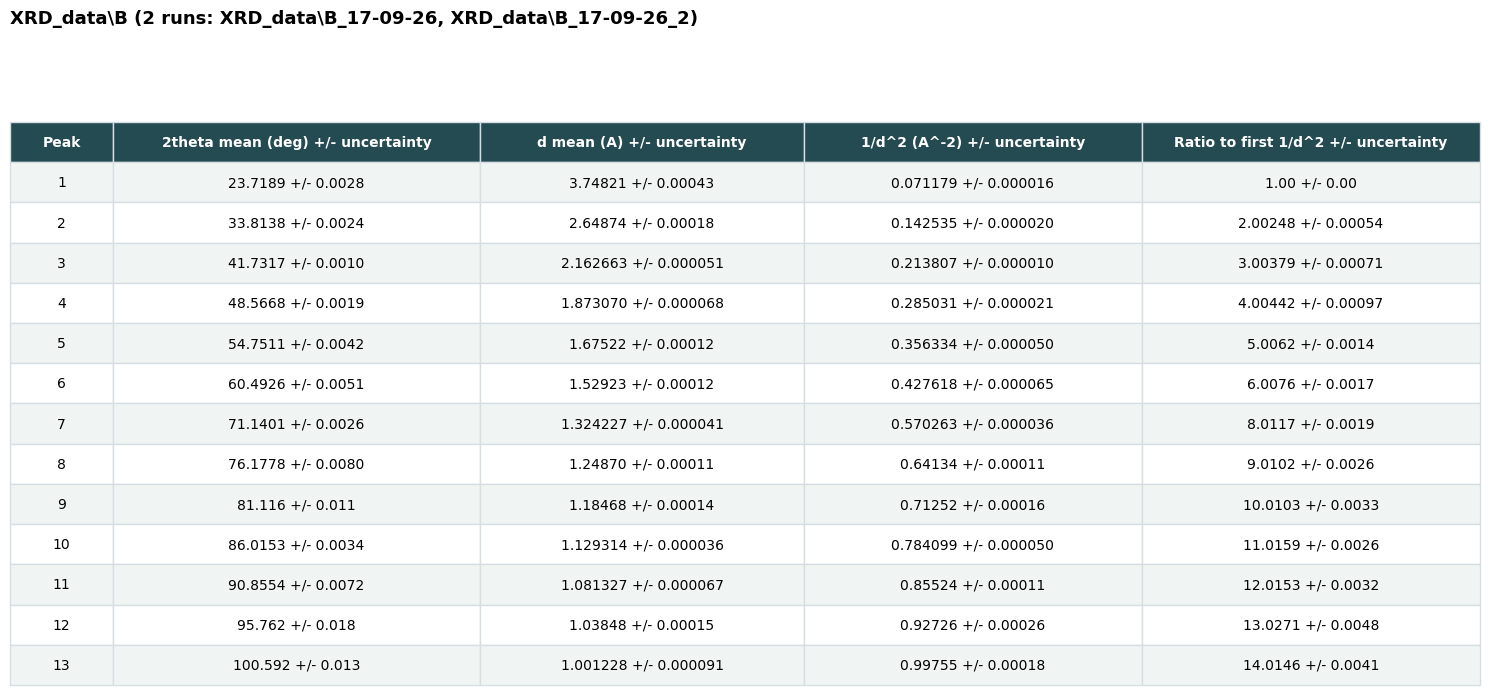

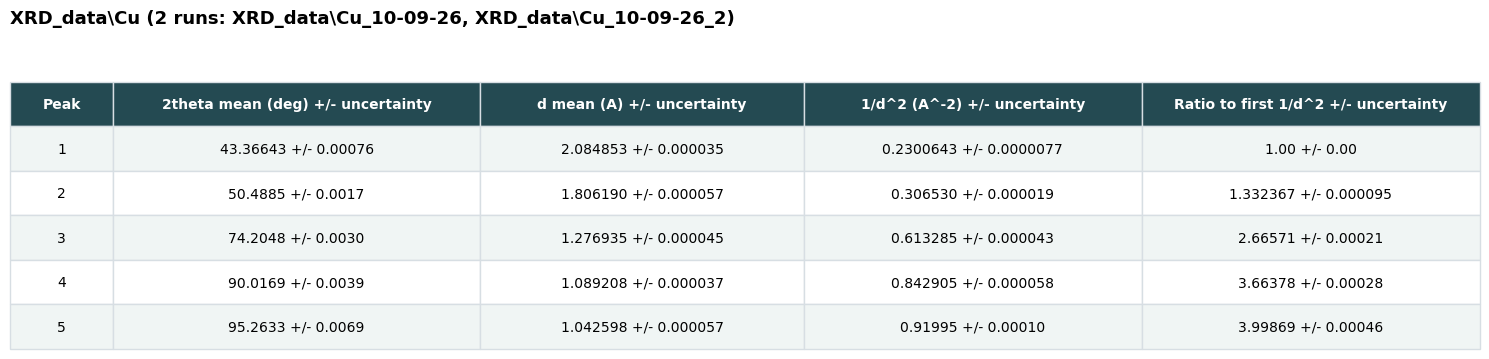

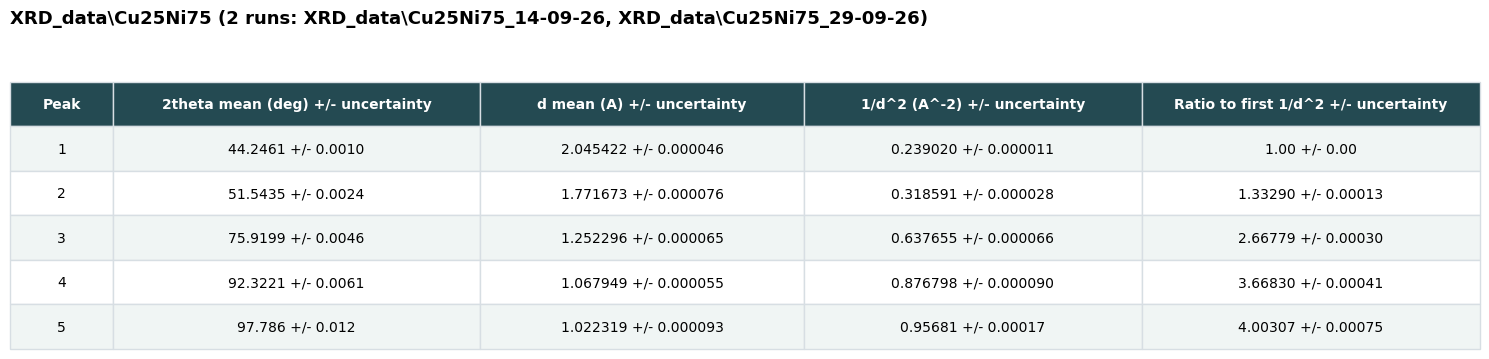

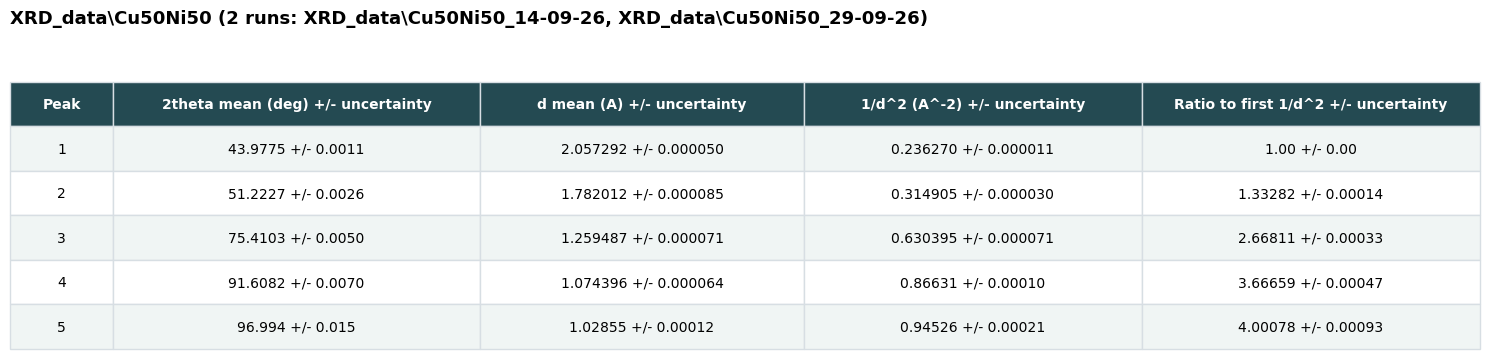

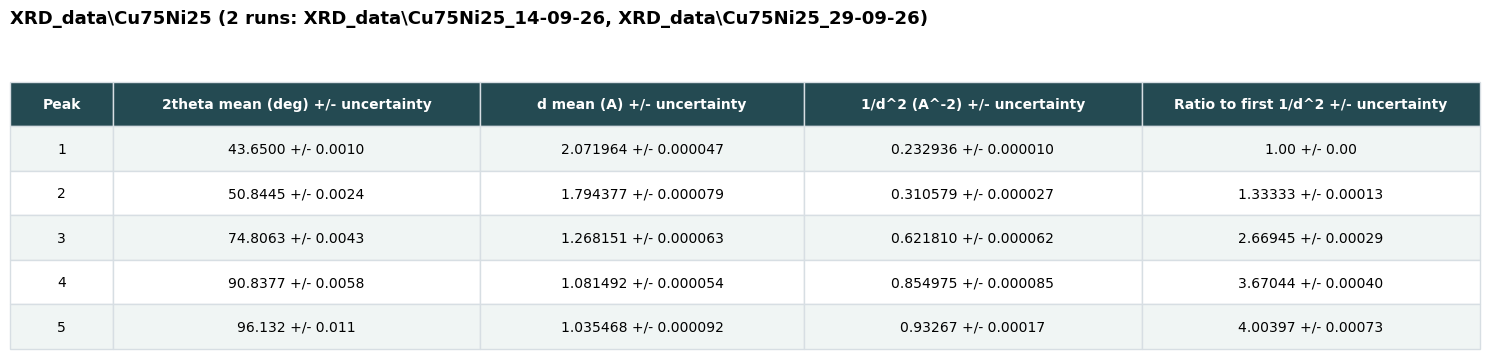

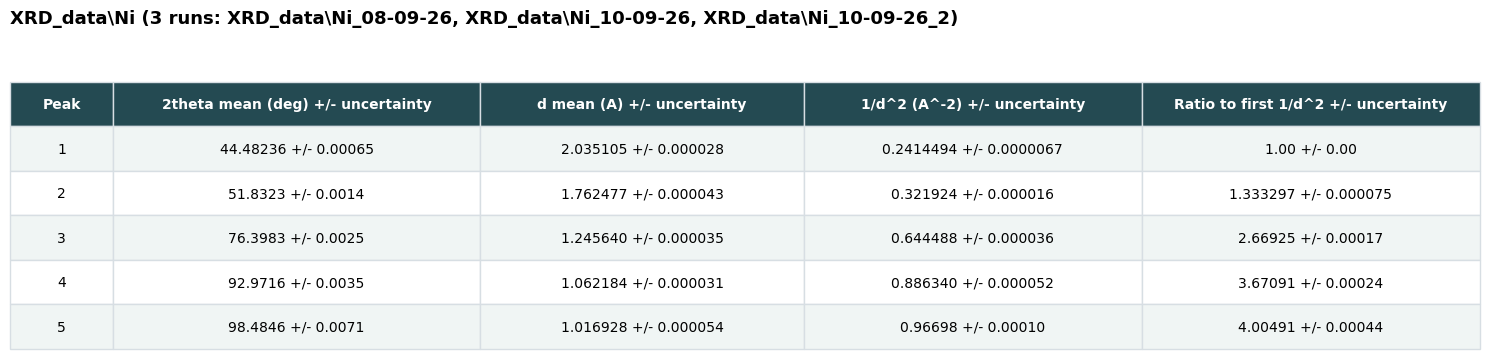

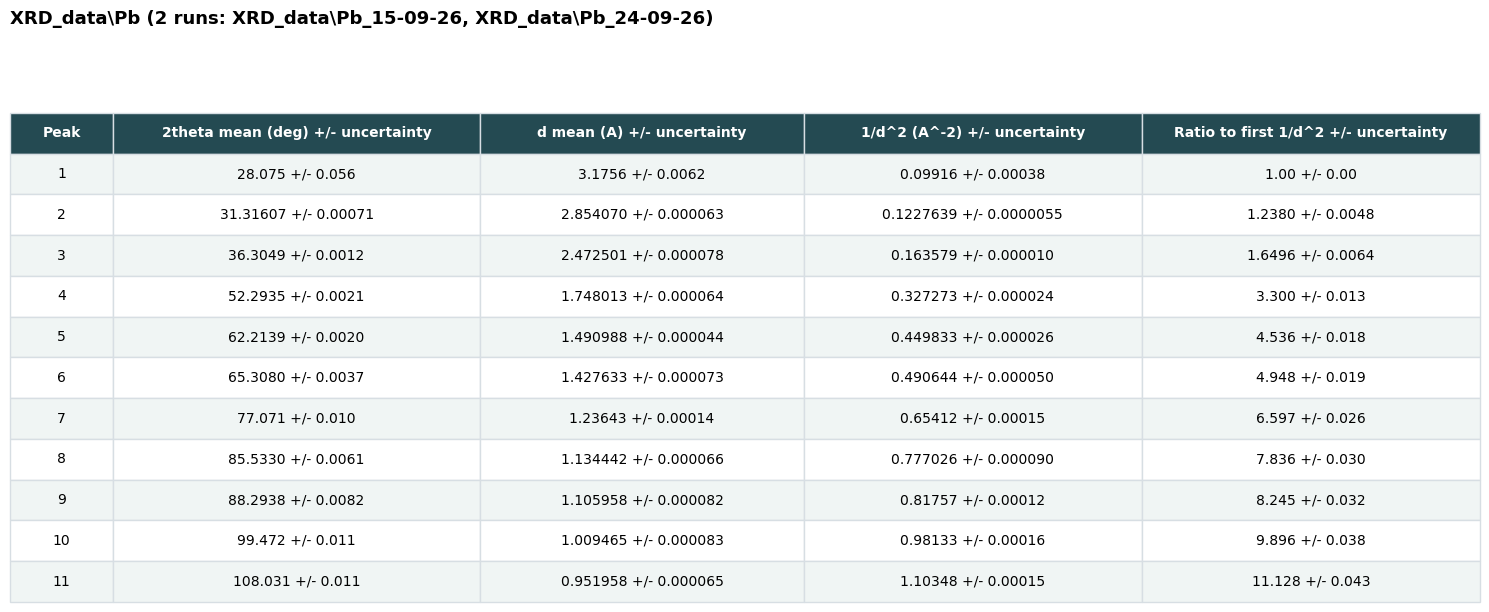

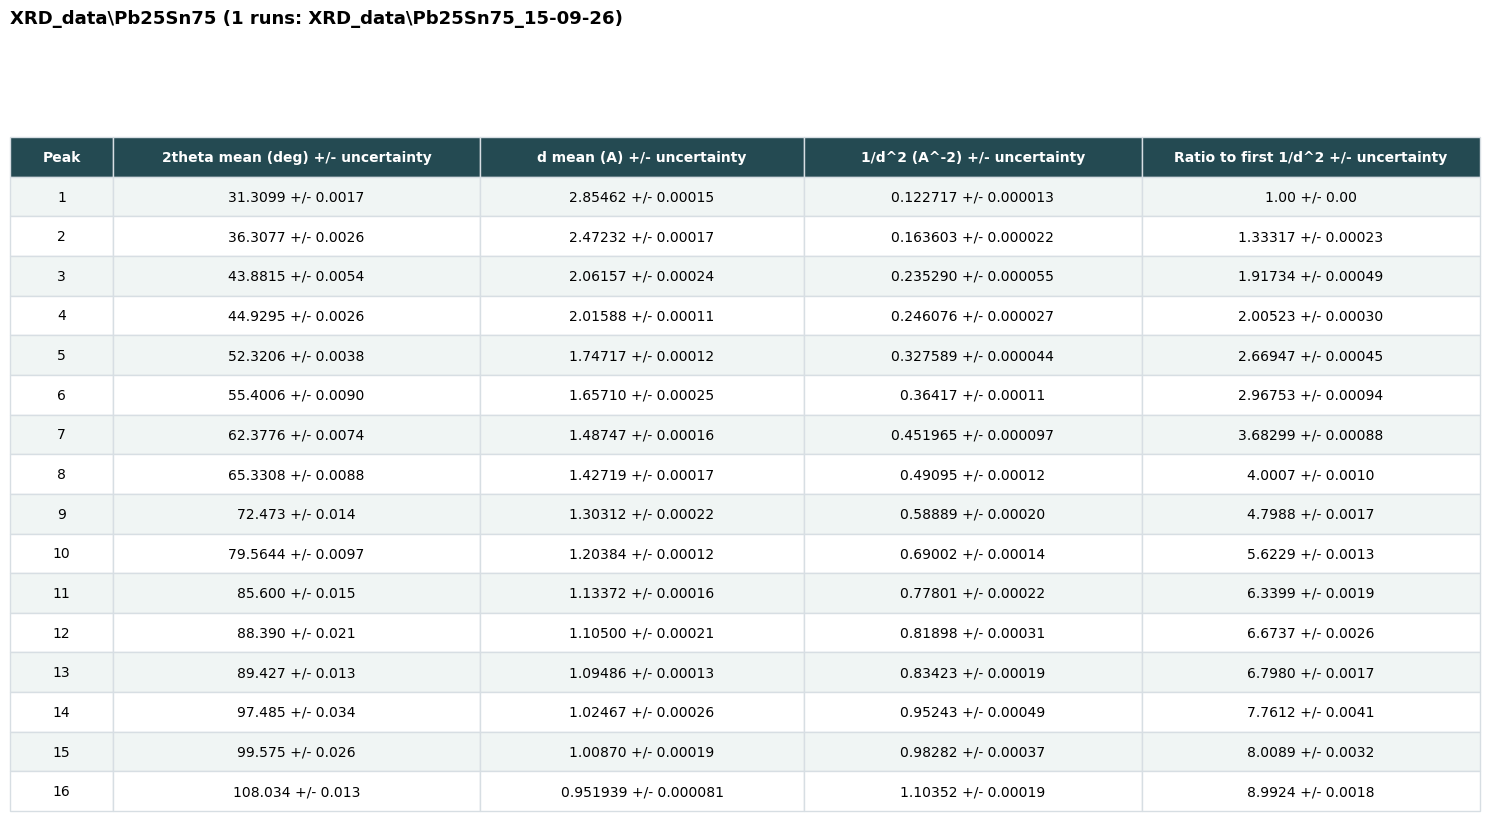

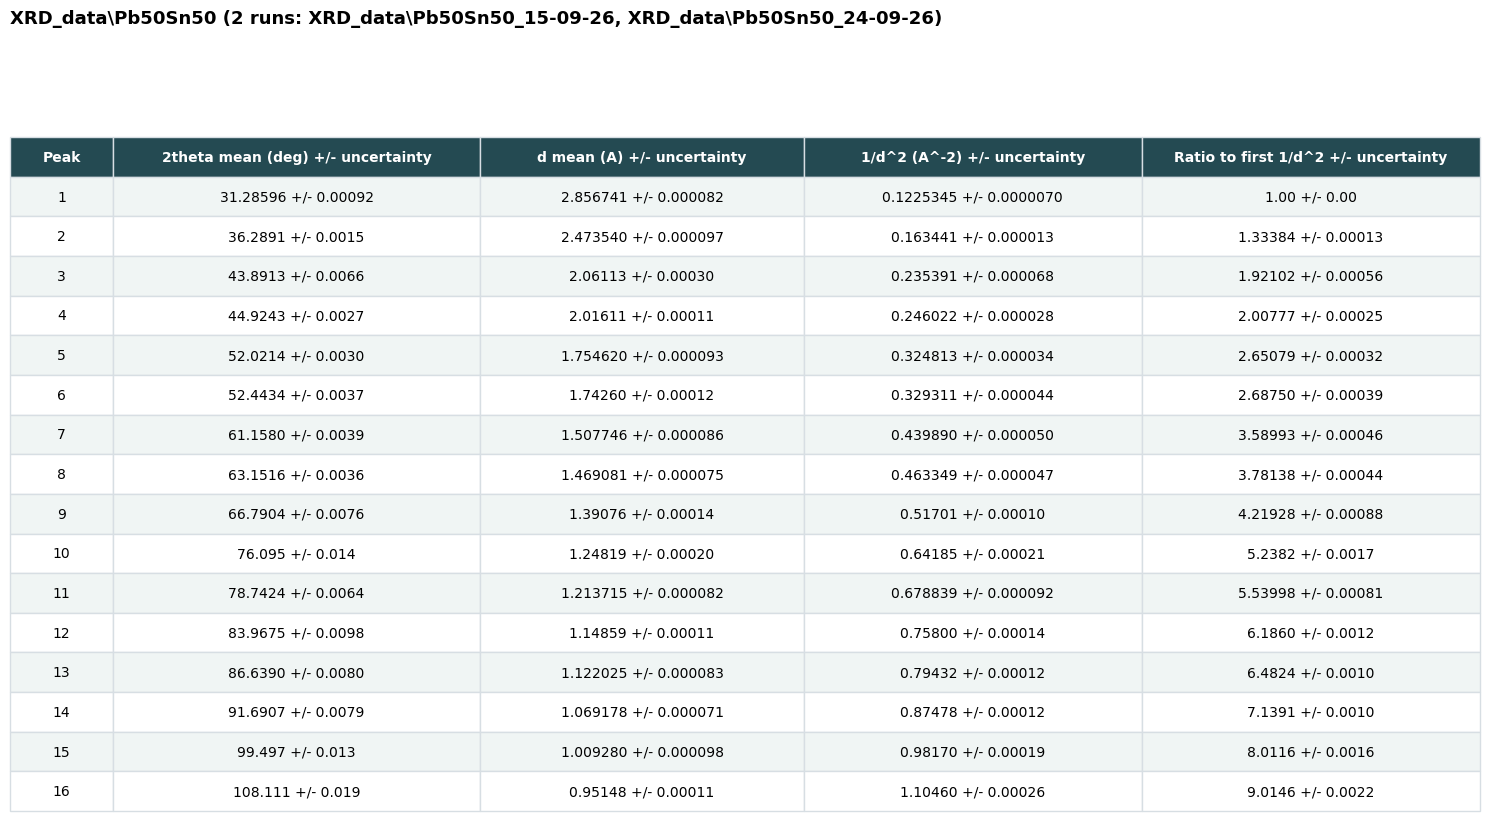

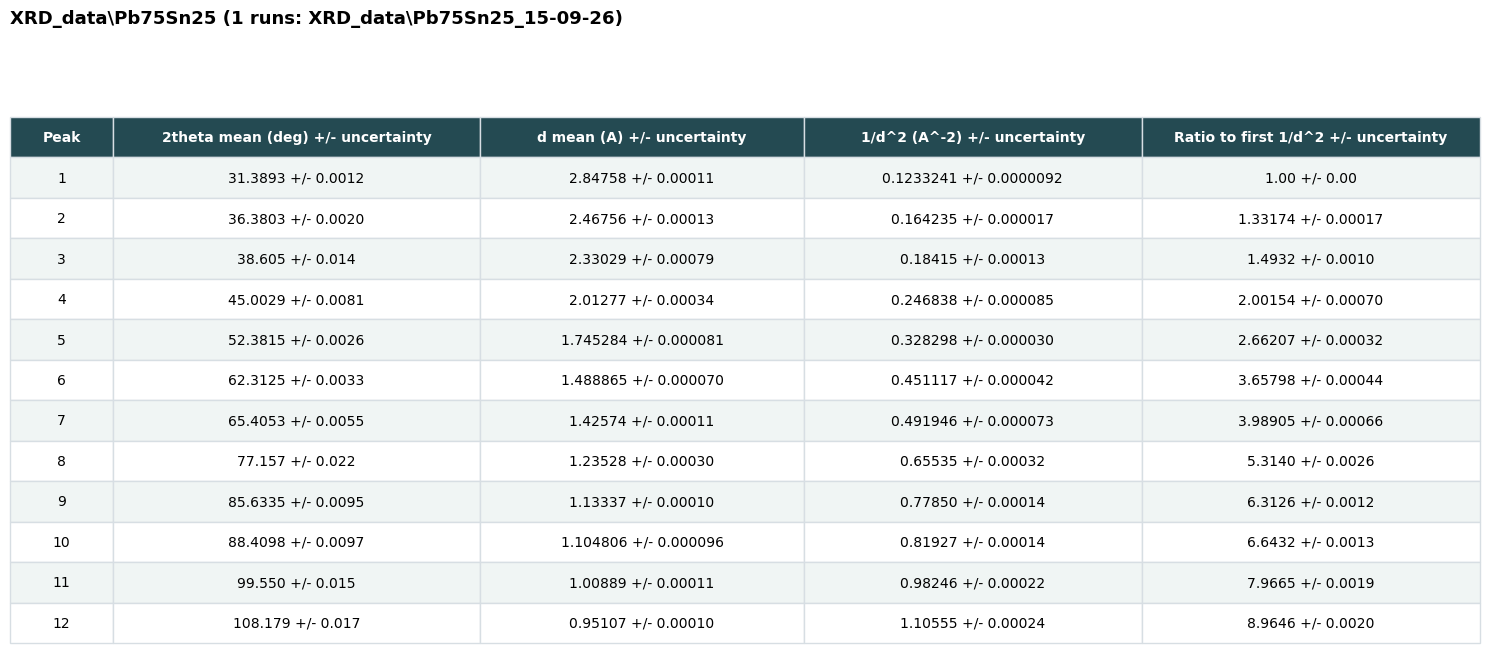

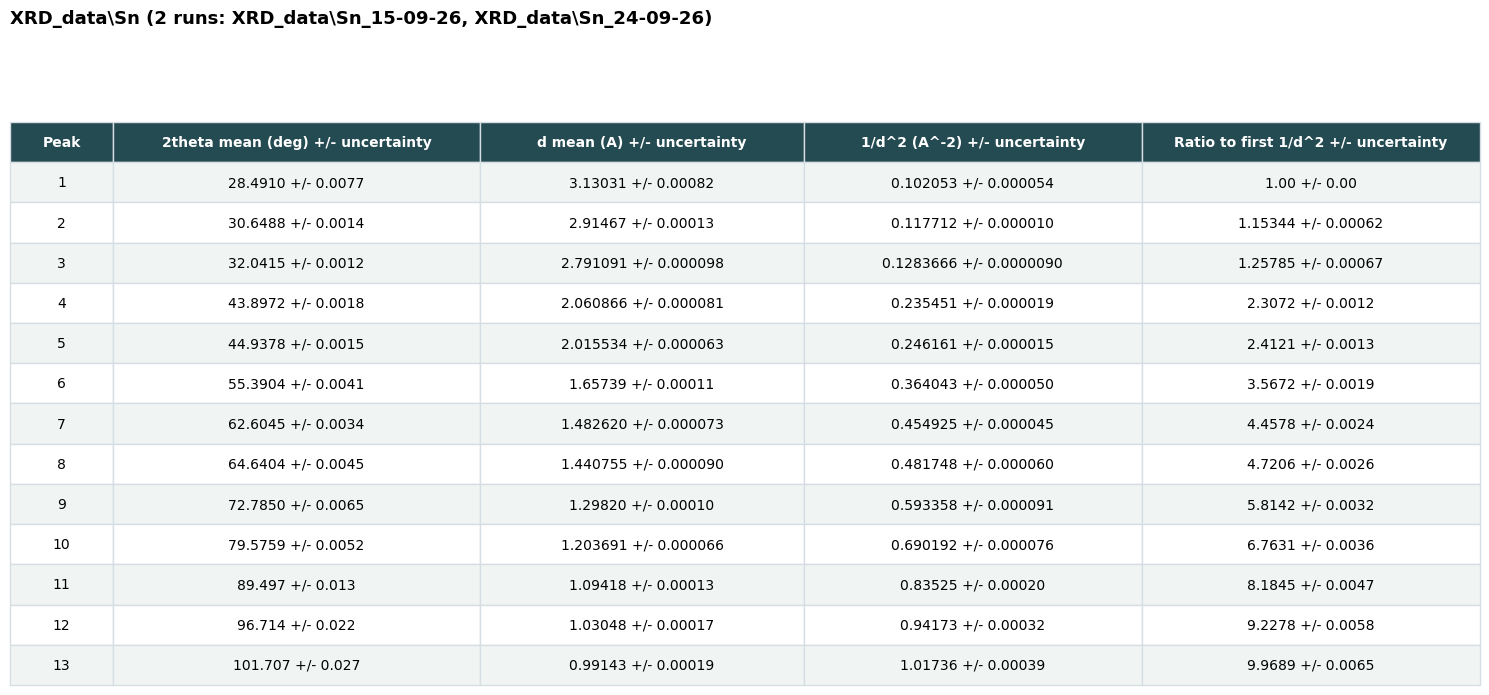

In [21]:
import re
from collections import defaultdict


def weighted_mean_with_uncertainty(values, uncertainties):
    values = np.asarray(values, dtype=float)
    uncertainties = np.asarray(uncertainties, dtype=float)
    valid = (
        np.isfinite(values)
        & np.isfinite(uncertainties)
        & (uncertainties > 0)
    )
    values = values[valid]
    uncertainties = uncertainties[valid]

    if len(values) == 0:
        return np.nan, np.nan

    weights = 1 / uncertainties**2
    mean = np.sum(weights * values) / np.sum(weights)
    uncertainty = 1 / np.sqrt(np.sum(weights))
    return mean, uncertainty


def format_value_uncertainty(value, uncertainty, significant_figures=2):
    value = float(value)
    uncertainty = float(uncertainty)
    if not np.isfinite(value) or not np.isfinite(uncertainty):
        return f"{value} +/- {uncertainty}"
    if uncertainty == 0:
        return f"{value:.2f} +/- 0.00"

    exponent = int(np.floor(np.log10(abs(uncertainty))))
    decimal_places = significant_figures - 1 - exponent
    rounded_uncertainty = round(uncertainty, decimal_places)
    if rounded_uncertainty >= 10 ** (exponent + 1):
        exponent += 1
        decimal_places -= 1

    if decimal_places >= 0:
        return (
            f"{value:.{decimal_places}f} +/- "
            f"{uncertainty:.{decimal_places}f}"
        )

    scale = 10.0**exponent
    mantissa_places = significant_figures - 1
    return (
        f"{value / scale:.{mantissa_places}f}e{exponent:+d} +/- "
        f"{uncertainty / scale:.{mantissa_places}f}e{exponent:+d}"
    )


runs_by_sample = defaultdict(list)
for run_name in peak_angles:
    sample_name = re.sub(r"_\d{2}-\d{2}-\d{2}(?:_\d+)?$", "", run_name)
    runs_by_sample[sample_name].append(run_name)

average_results = {}
for sample_name, run_names in sorted(runs_by_sample.items()):
    # Peaks are stored in increasing 2theta order, so matching uses peak index.
    peak_count = min(len(peak_angles[name]) for name in run_names)
    two_theta_means = []
    two_theta_uncertainties = []
    d_means = []
    d_uncertainties = []

    for peak_index in range(peak_count):
        two_theta_mean, two_theta_uncertainty = weighted_mean_with_uncertainty(
            [peak_angles[name][peak_index] for name in run_names],
            [peak_angle_errors[name][peak_index] for name in run_names],
        )
        d_mean, d_uncertainty = weighted_mean_with_uncertainty(
            [peak_d[name][peak_index] for name in run_names],
            [peak_d_errors[name][peak_index] for name in run_names],
        )
        two_theta_means.append(two_theta_mean)
        two_theta_uncertainties.append(two_theta_uncertainty)
        d_means.append(d_mean)
        d_uncertainties.append(d_uncertainty)

    inverse_d_squared = 1 / np.asarray(d_means)**2
    inverse_d_squared_uncertainties = (
        2 * np.asarray(d_uncertainties) / np.asarray(d_means)**3
    )
    ratio_to_first = inverse_d_squared / inverse_d_squared[0]
    ratio_uncertainties = np.zeros_like(ratio_to_first)
    ratio_uncertainties[1:] = np.abs(ratio_to_first[1:]) * np.sqrt(
        (inverse_d_squared_uncertainties[1:] / inverse_d_squared[1:])**2
        + (inverse_d_squared_uncertainties[0] / inverse_d_squared[0])**2
    )

    average_results[sample_name] = {
        "runs": run_names,
        "two_theta": np.asarray(two_theta_means),
        "two_theta_uncertainty": np.asarray(two_theta_uncertainties),
        "d": np.asarray(d_means),
        "d_uncertainty": np.asarray(d_uncertainties),
        "inverse_d_squared": inverse_d_squared,
        "inverse_d_squared_uncertainty": inverse_d_squared_uncertainties,
        "ratio_to_first": ratio_to_first,
        "ratio_to_first_uncertainty": ratio_uncertainties,
    }

    table_rows = [
        [
            str(peak_index + 1),
            format_value_uncertainty(angle, angle_error),
            format_value_uncertainty(spacing, spacing_error),
            format_value_uncertainty(inv_d2, inv_d2_error),
            format_value_uncertainty(ratio, ratio_error),
        ]
        for peak_index, (
            angle,
            angle_error,
            spacing,
            spacing_error,
            inv_d2,
            inv_d2_error,
            ratio,
            ratio_error,
        ) in enumerate(zip(
            two_theta_means,
            two_theta_uncertainties,
            d_means,
            d_uncertainties,
            inverse_d_squared,
            inverse_d_squared_uncertainties,
            ratio_to_first,
            ratio_uncertainties,
        ))
    ]

    fig, ax = plt.subplots(figsize=(15, max(2.5, 0.42 * len(table_rows) + 1.6)))
    ax.axis("off")
    ax.set_title(
        f"{sample_name} ({len(run_names)} runs: {', '.join(run_names)})",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=16,
    )
    table = ax.table(
        cellText=table_rows,
        colLabels=[
            "Peak",
            "2theta mean (deg) +/- uncertainty",
            "d mean (A) +/- uncertainty",
            "1/d^2 (A^-2) +/- uncertainty",
            "Ratio to first 1/d^2 +/- uncertainty",
        ],
        colWidths=[0.07, 0.25, 0.22, 0.23, 0.23],
        cellLoc="center",
        bbox=[0, 0, 1, 0.88],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor("#D7DEE3")
        if row == 0:
            cell.set_facecolor("#244A52")
            cell.set_text_props(color="white", weight="bold")
        else:
            cell.set_facecolor("#F0F5F4" if row % 2 else "white")

    fig.tight_layout()
    plt.show()

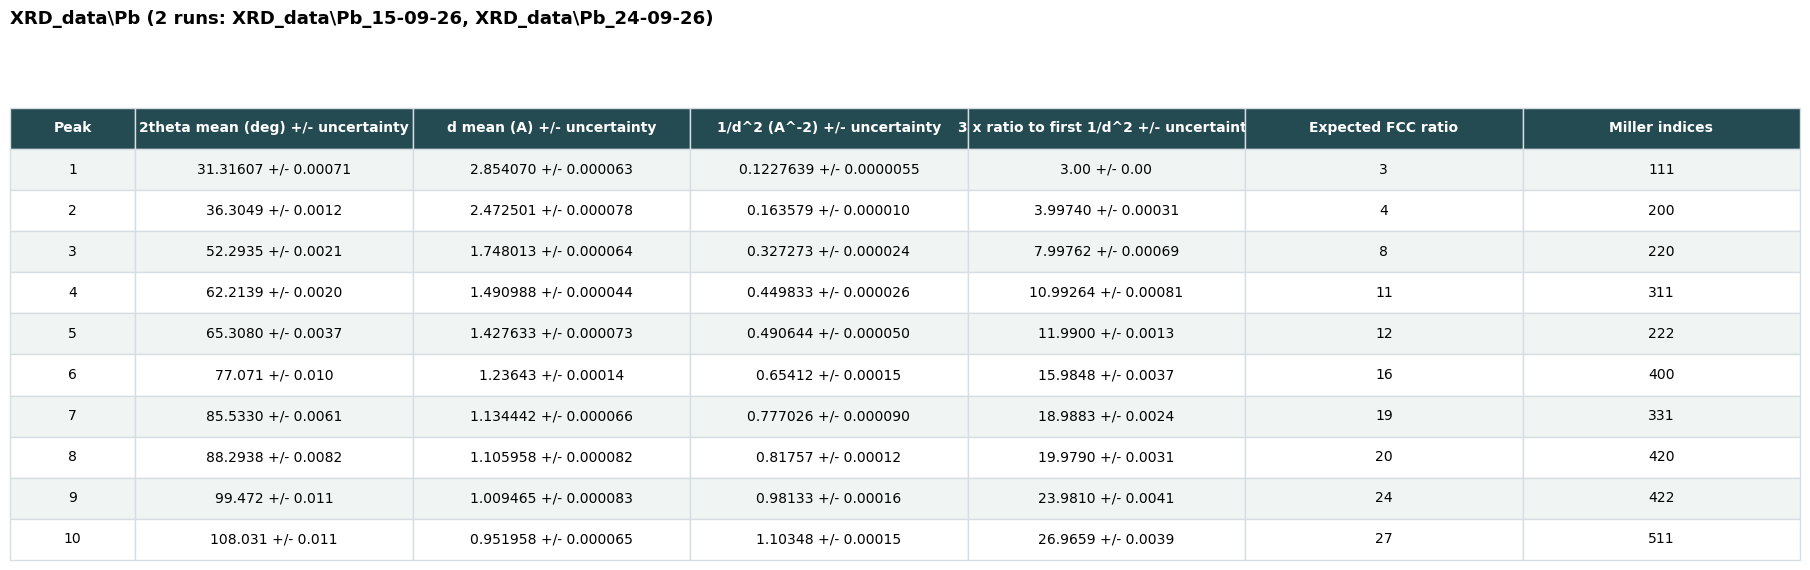

In [22]:
# Work with one sample at a time. Change this to another sample name if needed.
SAMPLE_NAME = "Pb"

sample_key = SAMPLE_NAME if SAMPLE_NAME in average_results else None
if sample_key is None:
    sample_matches = [
        name for name in average_results
        if name.replace("\\", "/").rstrip("/").split("/")[-1] == SAMPLE_NAME
    ]
    if len(sample_matches) != 1:
        available = ", ".join(sorted(average_results))
        if not sample_matches:
            raise KeyError(f"No sample named {SAMPLE_NAME!r}. Available: {available}")
        raise ValueError(
            f"{SAMPLE_NAME!r} matches multiple samples: {sample_matches}. "
            "Set SAMPLE_NAME to the full sample key."
        )
    sample_key = sample_matches[0]

sample = average_results[sample_key]
peak_count = len(sample["two_theta"])
if peak_count < 2:
    raise ValueError(f"{sample_key!r} needs at least two peaks to show peaks after excluding the first.")

# Exclude the original first peak from every table column. (clearly bs)
display_slice = slice(1, None)
display_peak_count = peak_count - 1
inverse_d_squared = sample["inverse_d_squared"][display_slice]
inverse_d_squared_uncertainties = sample["inverse_d_squared_uncertainty"][display_slice]
ratio_to_first = inverse_d_squared / inverse_d_squared[0]
ratio_to_first_uncertainties = np.abs(ratio_to_first) * np.sqrt(
    (inverse_d_squared_uncertainties / inverse_d_squared)**2
    + (inverse_d_squared_uncertainties[0] / inverse_d_squared[0])**2
)
ratio_to_first_uncertainties[0] = 0.0
ratio_to_first_times_three = 3 * ratio_to_first
ratio_to_first_times_three_uncertainties = 3 * ratio_to_first_uncertainties
# Add custom columns here; each needs one value per peak.
extra_columns = {}
# Example: extra_columns["d rounded (A)"] = np.round(sample["d"], 3)
for column_name, values in extra_columns.items():
    if len(values) != peak_count:
        raise ValueError(
            f"Column {column_name!r} has {len(values)} values; expected {peak_count}."
        )

metrics = [
    ("2theta mean (deg) +/- uncertainty", "two_theta", "two_theta_uncertainty"),
    ("d mean (A) +/- uncertainty", "d", "d_uncertainty"),
    ("1/d^2 (A^-2) +/- uncertainty", "inverse_d_squared", "inverse_d_squared_uncertainty"),
]
sample_columns = [("Peak", [str(i + 1) for i in range(display_peak_count)])]
for label, value_key, error_key in metrics:
    sample_columns.append((
        label,
        [
            format_value_uncertainty(value, error)
            for value, error in zip(
                sample[value_key][display_slice],
                sample[error_key][display_slice],
            )
        ],
    ))
sample_columns.append((
    "3 x ratio to first 1/d^2 +/- uncertainty",
    [
        format_value_uncertainty(value, error)
        for value, error in zip(
            ratio_to_first_times_three,
            ratio_to_first_times_three_uncertainties,
        )
    ],
))
sample_columns.extend(
    (label, values[display_slice])
    for label, values in extra_columns.items()
)
miller_indices = ["111", "200", "220", "311", "222", "400", "331", "420", "422", "511"]
if len(miller_indices) != display_peak_count:
    raise ValueError(
        f"Miller-index list has {len(miller_indices)} entries; "
        f"expected {display_peak_count} for the displayed peaks."
    )
fcc_expected_ratios = [sum(int(value)**2 for value in index) for index in miller_indices]
sample_columns.append(("Expected FCC ratio", fcc_expected_ratios))
sample_columns.append(("Miller indices", miller_indices))

column_labels = [label for label, _ in sample_columns]
table_rows = [
    [str(values[row]) for _, values in sample_columns]
    for row in range(display_peak_count)
]
fig, ax = plt.subplots(
    figsize=(max(13, 2.6 * len(column_labels)), max(2.5, 0.42 * display_peak_count + 1.6))
)
ax.axis("off")
ax.set_title(
    f"{sample_key} ({len(sample['runs'])} runs: {', '.join(sample['runs'])})",
    loc="left", fontsize=13, fontweight="bold", pad=16,
)
column_widths = [0.07] + [0.93 / (len(column_labels) - 1)] * (len(column_labels) - 1)
table = ax.table(
    cellText=table_rows,
    colLabels=column_labels,
    colWidths=column_widths,
    cellLoc="center",
    bbox=[0, 0, 1, 0.88],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("#D7DEE3")
    if row == 0:
        cell.set_facecolor("#244A52")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F0F5F4" if row % 2 else "white")
fig.tight_layout()
plt.show()

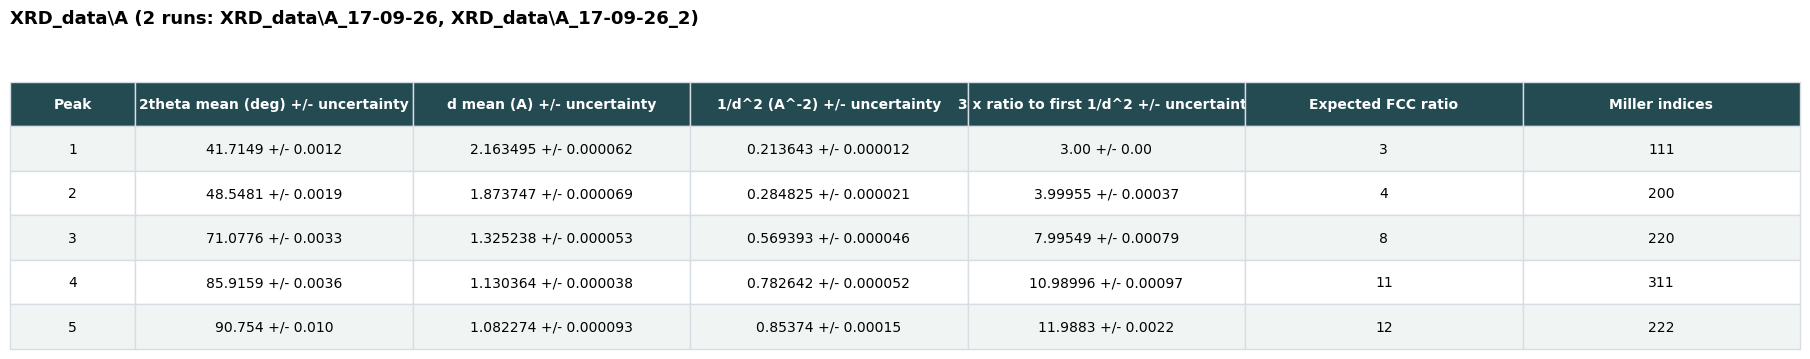

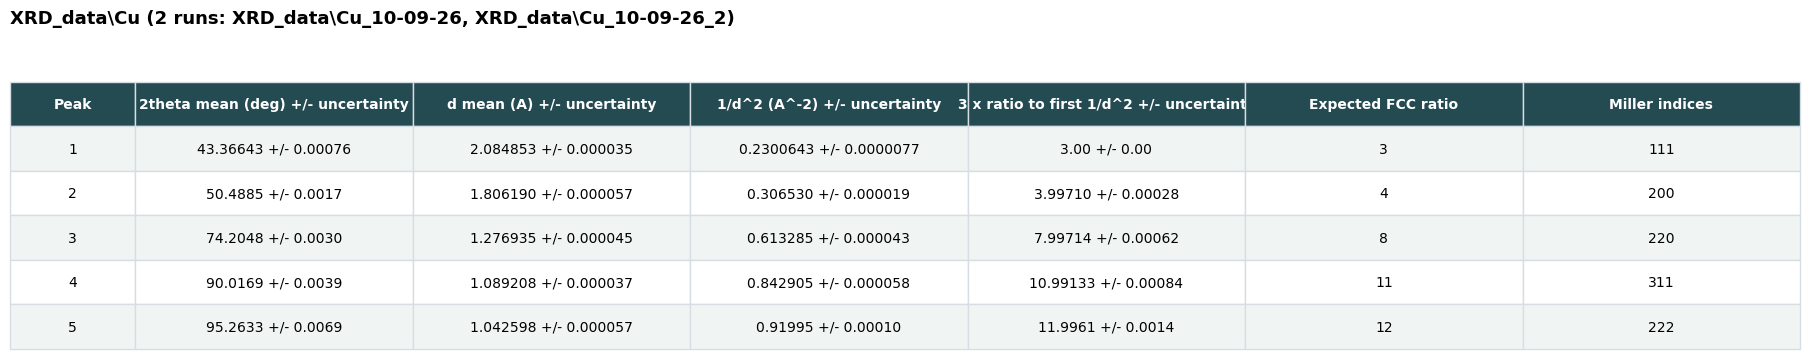

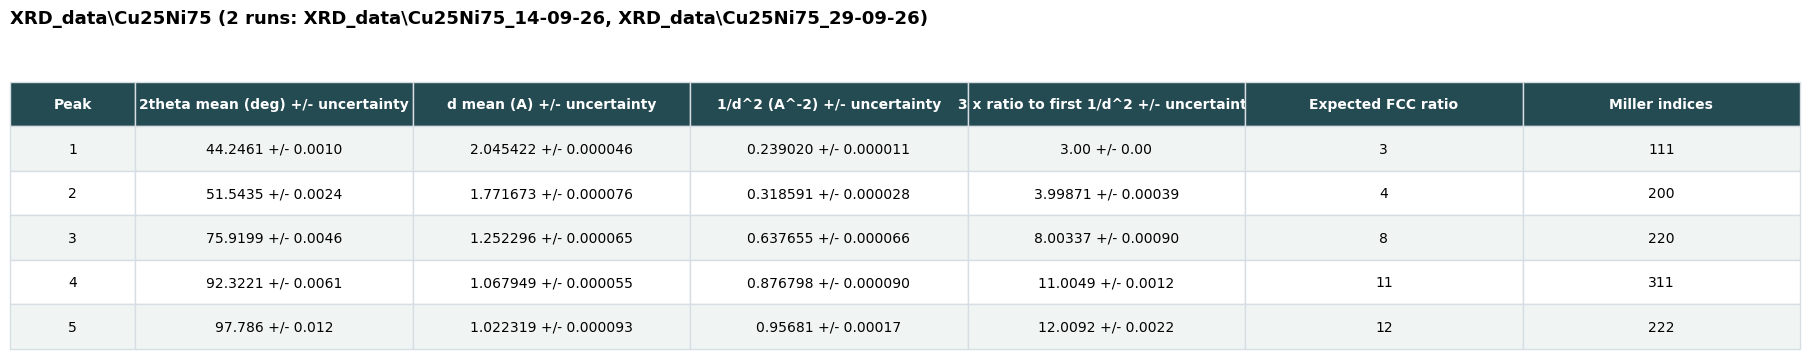

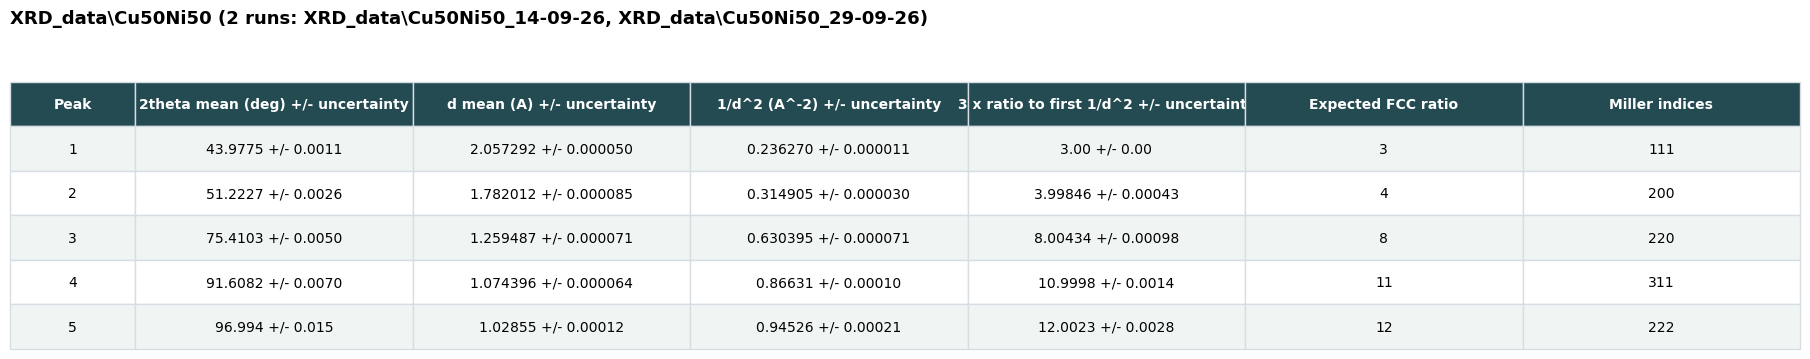

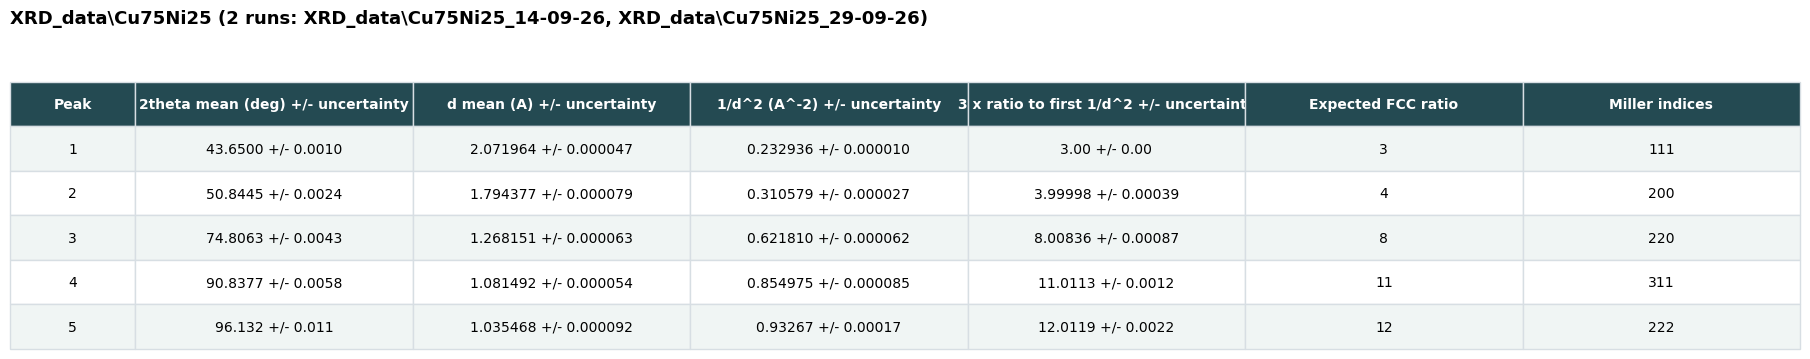

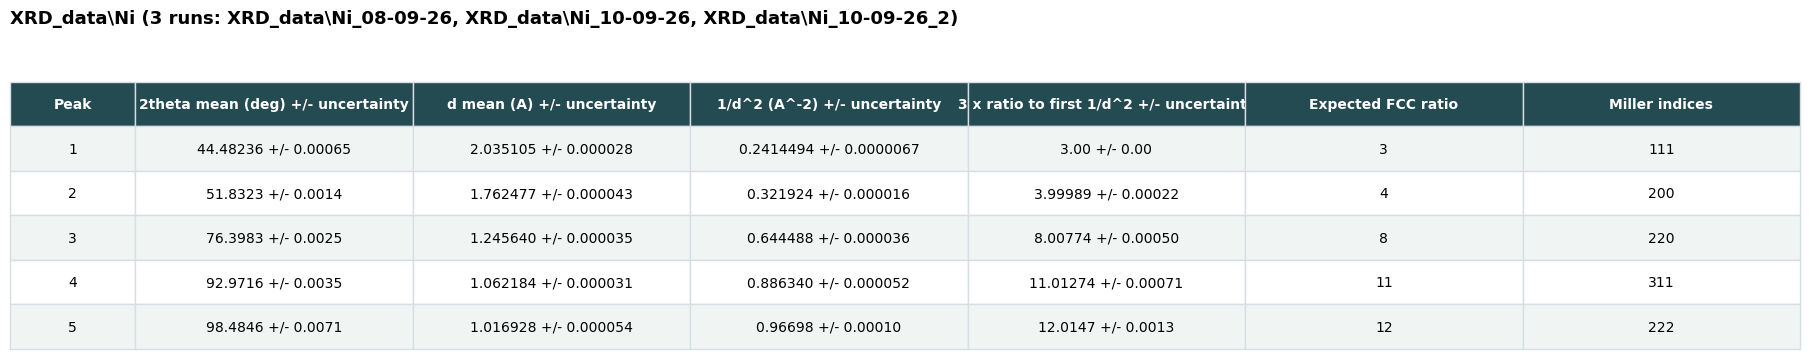

In [23]:
# Tables for Cu, Ni, and Cu-Ni alloys, retaining the first peak.
miller_index_values = ["111", "200", "220", "311", "222", "400", "331", "420", "422", "511"]
fcc_expected_ratio_values = [sum(int(value)**2 for value in index) for index in miller_index_values]
cuni_sample_keys = []
for result_key in sorted(average_results):
    sample_label = re.sub(
        r"_\d{2}-\d{2}-\d{2}(?:_\d+)?$",
        "",
        result_key.replace("\\", "/").rstrip("/").rsplit("/", 1)[-1],
    )
    if re.fullmatch(r"(?:A|Cu|Ni|Cu\d+Ni\d+)", sample_label):
        cuni_sample_keys.append(result_key)

if not cuni_sample_keys:
    raise KeyError("No Cu, Ni, or Cu-Ni alloy samples were found in average_results.")

for cuni_sample_key in cuni_sample_keys:
    cuni_sample = average_results[cuni_sample_key]
    cuni_peak_count = len(cuni_sample["two_theta"])
    if cuni_peak_count > len(miller_index_values):
        raise ValueError(
            f"{cuni_sample_key!r} has {cuni_peak_count} peaks, but only "
            f"{len(miller_index_values)} Miller indices were provided."
        )

    cuni_inverse_d_squared = cuni_sample["inverse_d_squared"]
    cuni_inverse_d_squared_uncertainties = cuni_sample["inverse_d_squared_uncertainty"]
    cuni_ratio_to_first = cuni_inverse_d_squared / cuni_inverse_d_squared[0]
    cuni_ratio_uncertainties = np.abs(cuni_ratio_to_first) * np.sqrt(
        (cuni_inverse_d_squared_uncertainties / cuni_inverse_d_squared)**2
        + (cuni_inverse_d_squared_uncertainties[0] / cuni_inverse_d_squared[0])**2
    )
    cuni_ratio_uncertainties[0] = 0.0
    cuni_ratio_times_three = 3 * cuni_ratio_to_first
    cuni_ratio_times_three_uncertainties = 3 * cuni_ratio_uncertainties

    cuni_columns = [("Peak", [str(i + 1) for i in range(cuni_peak_count)])]
    for label, value_key, error_key in [
        ("2theta mean (deg) +/- uncertainty", "two_theta", "two_theta_uncertainty"),
        ("d mean (A) +/- uncertainty", "d", "d_uncertainty"),
        ("1/d^2 (A^-2) +/- uncertainty", "inverse_d_squared", "inverse_d_squared_uncertainty"),
    ]:
        cuni_columns.append((
            label,
            [
                format_value_uncertainty(value, error)
                for value, error in zip(cuni_sample[value_key], cuni_sample[error_key])
            ],
        ))
    cuni_columns.append((
        "3 x ratio to first 1/d^2 +/- uncertainty",
        [
            format_value_uncertainty(value, error)
            for value, error in zip(
                cuni_ratio_times_three,
                cuni_ratio_times_three_uncertainties,
            )
        ],
    ))
    cuni_columns.append(("Expected FCC ratio", fcc_expected_ratio_values[:cuni_peak_count]))
    cuni_columns.append(("Miller indices", miller_index_values[:cuni_peak_count]))

    cuni_column_labels = [label for label, _ in cuni_columns]
    cuni_table_rows = [
        [str(values[row]) for _, values in cuni_columns]
        for row in range(cuni_peak_count)
    ]
    fig, ax = plt.subplots(
        figsize=(max(13, 2.6 * len(cuni_column_labels)), max(2.5, 0.42 * cuni_peak_count + 1.6))
    )
    ax.axis("off")
    ax.set_title(
        f"{cuni_sample_key} ({len(cuni_sample['runs'])} runs: {', '.join(cuni_sample['runs'])})",
        loc="left", fontsize=13, fontweight="bold", pad=16,
    )
    cuni_column_widths = [0.07] + [0.93 / (len(cuni_column_labels) - 1)] * (len(cuni_column_labels) - 1)
    table = ax.table(
        cellText=cuni_table_rows,
        colLabels=cuni_column_labels,
        colWidths=cuni_column_widths,
        cellLoc="center",
        bbox=[0, 0, 1, 0.88],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor("#D7DEE3")
        if row == 0:
            cell.set_facecolor("#244A52")
            cell.set_text_props(color="white", weight="bold")
        else:
            cell.set_facecolor("#F0F5F4" if row % 2 else "white")
    fig.tight_layout()
    plt.show()

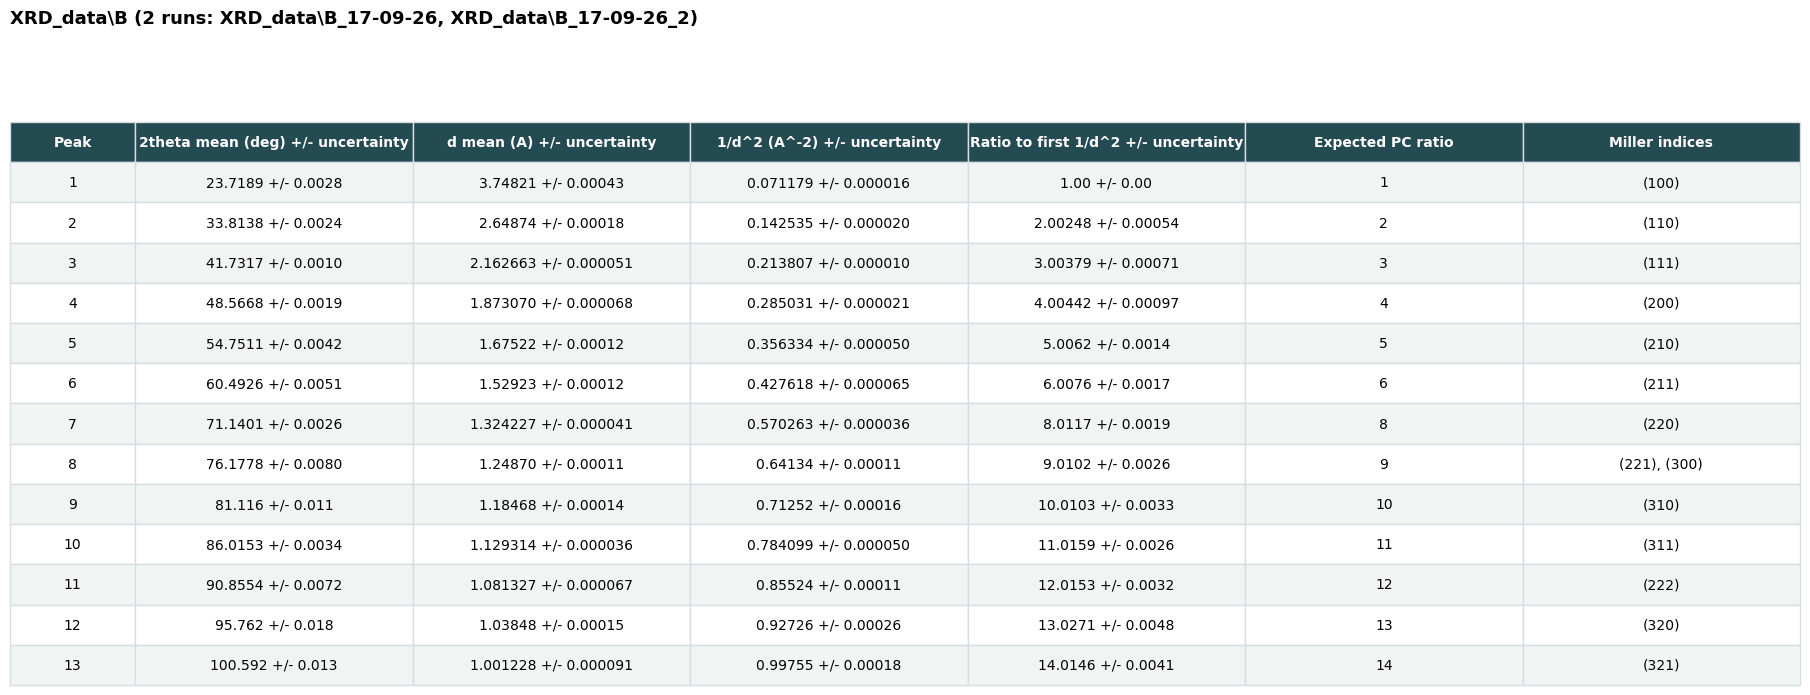

In [26]:
# B table with primitive-cubic expected ratios and Miller indices added.
sample_name_b = "B"
sample_matches_b = [
    name for name in average_results
    if name.replace("\\", "/").rstrip("/").split("/")[-1] == sample_name_b
]
if len(sample_matches_b) != 1:
    available_b = ", ".join(sorted(average_results))
    if not sample_matches_b:
        raise KeyError(f"No sample named {sample_name_b!r}. Available: {available_b}")
    raise ValueError(f"{sample_name_b!r} matches multiple samples: {sample_matches_b}.")
sample_key_b = sample_matches_b[0]
sample_b = average_results[sample_key_b]
peak_count_b = len(sample_b["two_theta"])
if peak_count_b < 1:
    raise ValueError("Sample B needs at least one peak to build the table.")

inverse_d_squared_b = sample_b["inverse_d_squared"]
inverse_d_squared_errors_b = sample_b["inverse_d_squared_uncertainty"]
ratio_b = inverse_d_squared_b / inverse_d_squared_b[0]
ratio_errors_b = np.abs(ratio_b) * np.sqrt(
    (inverse_d_squared_errors_b / inverse_d_squared_b) ** 2
    + (inverse_d_squared_errors_b[0] / inverse_d_squared_b[0]) ** 2
)
ratio_errors_b[0] = 0.0

pc_expected_ratios = [ratio for ratio in range(1, 15) if ratio != 7]
pc_miller_indices = [
    "(100)", "(110)", "(111)", "(200)", "(210)", "(211)",
    "(220)", "(221), (300)", "(310)", "(311)", "(222)", "(320)", "(321)",
]
if peak_count_b > len(pc_expected_ratios):
    raise ValueError(
        f"Sample B has {peak_count_b} peaks, but only {len(pc_expected_ratios)} "
        "primitive-cubic expected ratios were specified."
    )

metrics_b = [
    ("2theta mean (deg) +/- uncertainty", "two_theta", "two_theta_uncertainty"),
    ("d mean (A) +/- uncertainty", "d", "d_uncertainty"),
    ("1/d^2 (A^-2) +/- uncertainty", "inverse_d_squared", "inverse_d_squared_uncertainty"),
]
columns_b = [("Peak", [str(i + 1) for i in range(peak_count_b)])]
for label_b, value_key_b, error_key_b in metrics_b:
    columns_b.append((
        label_b,
        [
            format_value_uncertainty(value, error)
            for value, error in zip(sample_b[value_key_b], sample_b[error_key_b])
        ],
    ))
columns_b.append((
    "Ratio to first 1/d^2 +/- uncertainty",
    [format_value_uncertainty(value, error) for value, error in zip(ratio_b, ratio_errors_b)],
))
columns_b.append(("Expected PC ratio", pc_expected_ratios))
columns_b.append(("Miller indices", pc_miller_indices))

table_row_count_b = max(len(values) for _, values in columns_b)
labels_b = [label for label, _ in columns_b]
rows_b = [
    [str(values[row]) if row < len(values) else "" for _, values in columns_b]
    for row in range(table_row_count_b)
]
fig_b, ax_b = plt.subplots(
    figsize=(max(13, 2.6 * len(labels_b)), max(2.5, 0.42 * table_row_count_b + 1.6))
)
ax_b.axis("off")
ax_b.set_title(
    f"{sample_key_b} ({len(sample_b['runs'])} runs: {', '.join(sample_b['runs'])})",
    loc="left", fontsize=13, fontweight="bold", pad=16,
)
column_widths_b = [0.07] + [0.93 / (len(labels_b) - 1)] * (len(labels_b) - 1)
table_b = ax_b.table(
    cellText=rows_b,
    colLabels=labels_b,
    colWidths=column_widths_b,
    cellLoc="center",
    bbox=[0, 0, 1, 0.88],
)
table_b.auto_set_font_size(False)
table_b.set_fontsize(10)
for (row_b, column_b), cell_b in table_b.get_celld().items():
    cell_b.set_edgecolor("#D7DEE3")
    if row_b == 0:
        cell_b.set_facecolor("#244A52")
        cell_b.set_text_props(color="white", weight="bold")
    else:
        cell_b.set_facecolor("#F0F5F4" if row_b % 2 else "white")
fig_b.tight_layout()
plt.show()

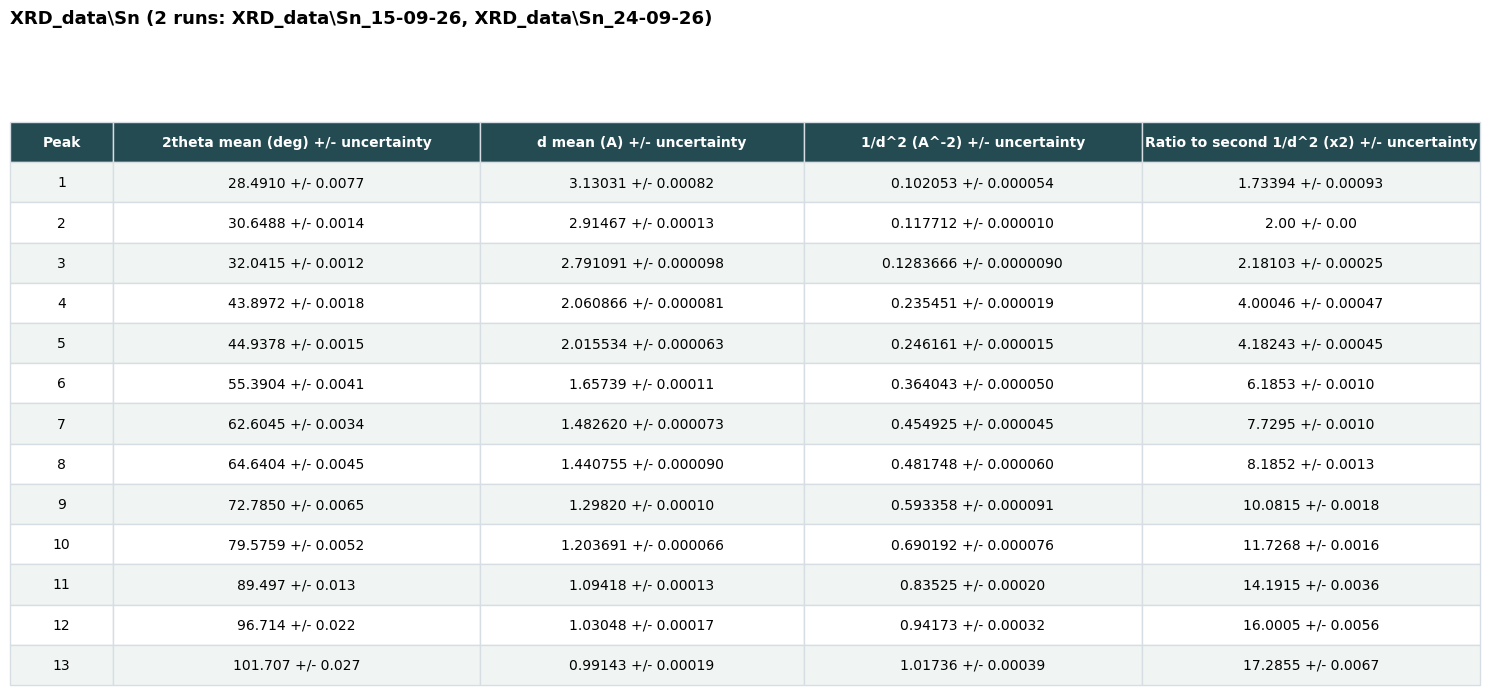

In [32]:
sample_key_sn = next(
    (
        key for key in average_results
        if key.rstrip("\\/").replace("/", "\\").split("\\")[-1].lower() == "sn"
    ),
    None,
)
if sample_key_sn is None:
    raise KeyError("No Sn sample was found in average_results.")

sample_sn = average_results[sample_key_sn]
if len(sample_sn["inverse_d_squared"]) < 2:
    raise ValueError("The Sn table needs at least two peaks to use peak 2 as the ratio reference.")

inverse_d_squared_sn = sample_sn["inverse_d_squared"]
inverse_d_squared_uncertainty_sn = sample_sn["inverse_d_squared_uncertainty"]
ratio_to_second_sn = inverse_d_squared_sn / inverse_d_squared_sn[1]
ratio_to_second_uncertainty_sn = np.abs(ratio_to_second_sn) * np.sqrt(
    (inverse_d_squared_uncertainty_sn / inverse_d_squared_sn)**2
    + (inverse_d_squared_uncertainty_sn[1] / inverse_d_squared_sn[1])**2
)
ratio_to_second_uncertainty_sn[1] = 0.0
ratio_to_second_sn *= 2
ratio_to_second_uncertainty_sn *= 2

table_rows_sn = [
    [
        str(peak_index + 1),
        format_value_uncertainty(angle, angle_error),
        format_value_uncertainty(spacing, spacing_error),
        format_value_uncertainty(inv_d2, inv_d2_error),
        format_value_uncertainty(ratio, ratio_error),
    ]
    for peak_index, (
        angle,
        angle_error,
        spacing,
        spacing_error,
        inv_d2,
        inv_d2_error,
        ratio,
        ratio_error,
    ) in enumerate(zip(
        sample_sn["two_theta"],
        sample_sn["two_theta_uncertainty"],
        sample_sn["d"],
        sample_sn["d_uncertainty"],
        sample_sn["inverse_d_squared"],
        sample_sn["inverse_d_squared_uncertainty"],
        ratio_to_second_sn,
        ratio_to_second_uncertainty_sn,
    ))
]

fig_sn, ax_sn = plt.subplots(
    figsize=(15, max(2.5, 0.42 * len(table_rows_sn) + 1.6))
)
ax_sn.axis("off")
ax_sn.set_title(
    f"{sample_key_sn} ({len(sample_sn['runs'])} runs: {', '.join(sample_sn['runs'])})",
    loc="left",
    fontsize=13,
    fontweight="bold",
    pad=16,
)
table_sn = ax_sn.table(
    cellText=table_rows_sn,
    colLabels=[
        "Peak",
        "2theta mean (deg) +/- uncertainty",
        "d mean (A) +/- uncertainty",
        "1/d^2 (A^-2) +/- uncertainty",
        "Ratio to second 1/d^2 (x2) +/- uncertainty",
    ],
    colWidths=[0.07, 0.25, 0.22, 0.23, 0.23],
    cellLoc="center",
    bbox=[0, 0, 1, 0.88],
)
table_sn.auto_set_font_size(False)
table_sn.set_fontsize(10)
for (row_sn, column_sn), cell_sn in table_sn.get_celld().items():
    cell_sn.set_edgecolor("#D7DEE3")
    if row_sn == 0:
        cell_sn.set_facecolor("#244A52")
        cell_sn.set_text_props(color="white", weight="bold")
    else:
        cell_sn.set_facecolor("#F0F5F4" if row_sn % 2 else "white")
fig_sn.tight_layout()
plt.show()